In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import ttest_ind, mannwhitneyu

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import SelectKBest, chi2
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import sklearn.preprocessing as preprocessing

### Load Data

In [2]:
df = pkl.load(open('project8.pkl', 'rb'))
df.shape

(2027, 19)

In [3]:
#group by subreddit and count the number of posts in each subreddit
grouped = df.groupby("subreddit")
grouped.size()

subreddit
climate_science     442
climateskeptics    1585
dtype: int64

### Statistical Summary

In [4]:
quants = ["score", "controversiality", "ups", "downs", "user_awardee_karma", "user_awarder_karma", "user_total_karma", "user_comment_karma", "user_link_karma"]
statistics = grouped[quants].agg(['mean', 'var']).round(3)
styled_statistics = statistics.T.style.format("{:.3f}") \
                                       .set_caption("Summary Statistics for Quantitative Variables") \
                                       .set_table_styles([
                                           {'selector': 'th', 'props': [('border', '1px solid black'), 
                                                                        ('padding', '10px'), 
                                                                        ('text-align', 'center'),
                                                                        ]},
                                           {'selector': 'td', 'props': [('border', '1px solid black'), 
                                                                        ('padding', '10px'), 
                                                                        ('text-align', 'center'),
                                                                        ]},
                                       ])
styled_statistics.to_html("summary_statistics.html")
styled_statistics


### Visualizing distribution

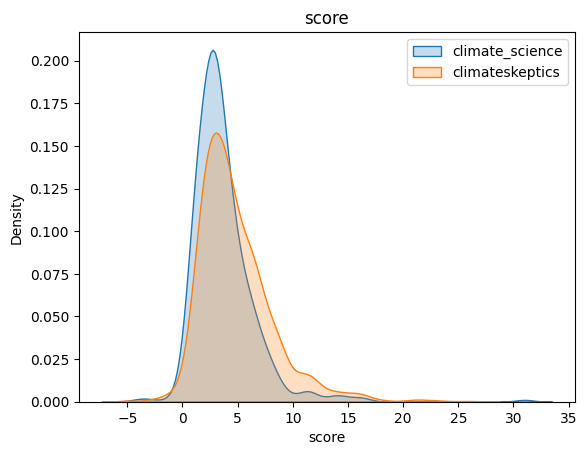

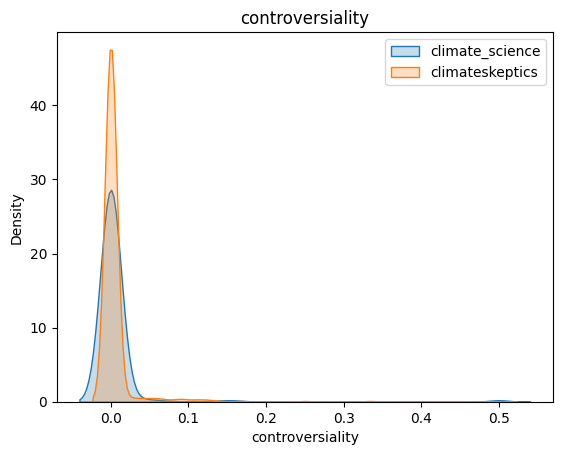

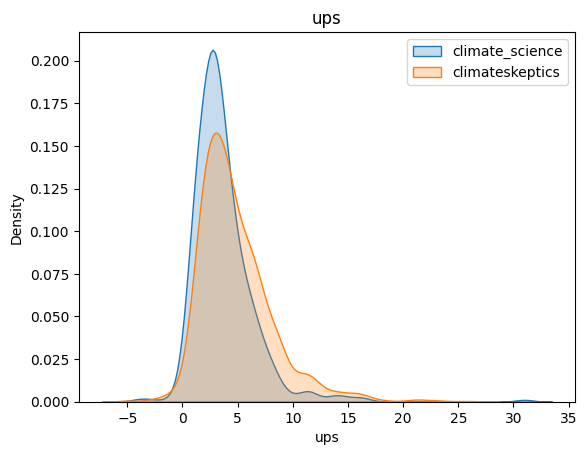

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


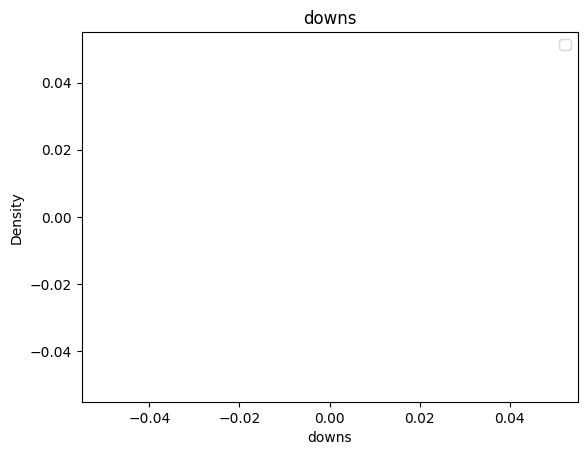

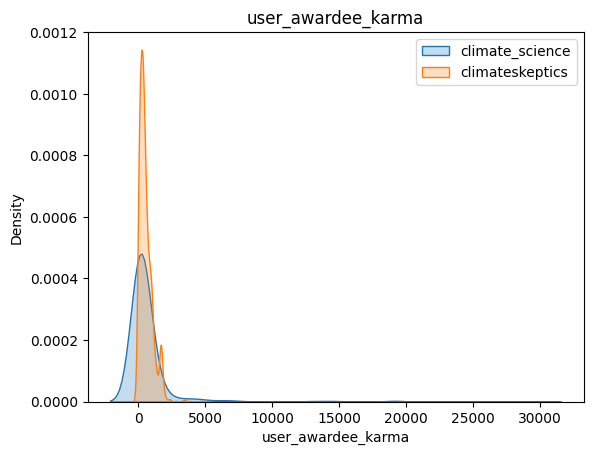

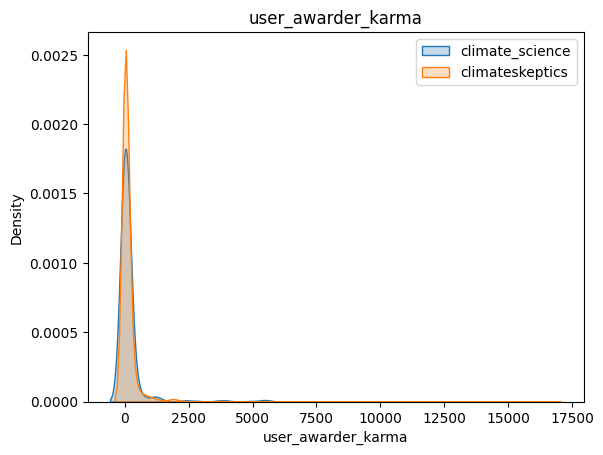

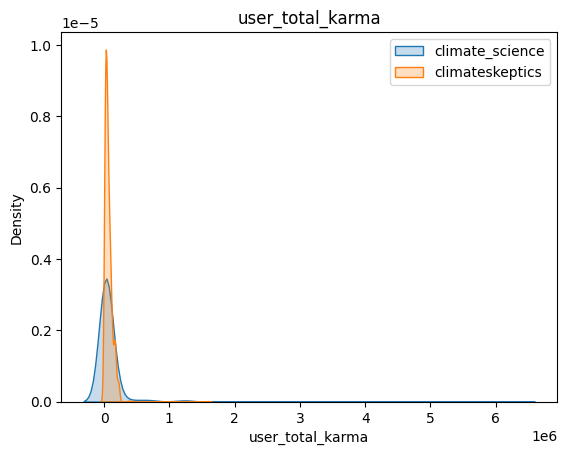

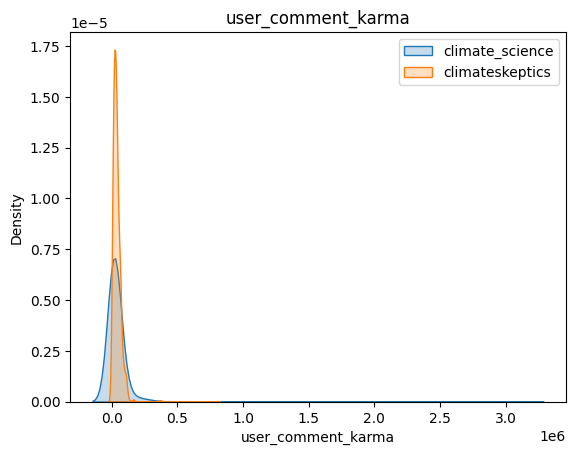

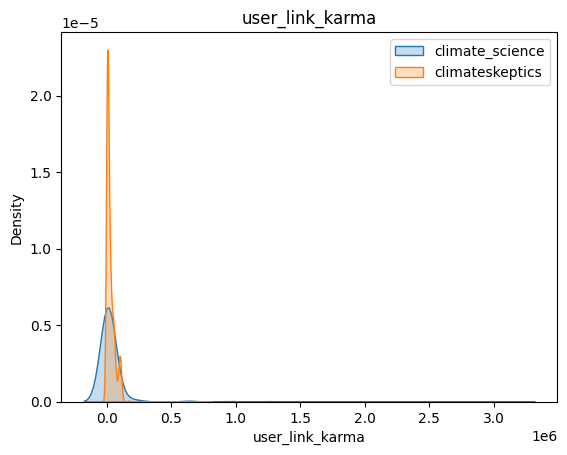

In [5]:
df_sci = grouped.get_group("climate_science")
df_skep = grouped.get_group("climateskeptics")

for feature in quants:
    sns.kdeplot(df_sci[feature], label="climate_science", shade=True)
    sns.kdeplot(df_skep[feature], label="climateskeptics", shade=True)
    plt.title(feature)
    plt.legend()
    plt.show()


### Statistical Testing

In [6]:
#t-test
stat_test_results = {}
for feature in quants:
    #remove nan values but do not modify the original dataframe
    sci = df_sci[feature].dropna()
    skep = df_skep[feature].dropna()
    if feature == "down":
        continue
    if feature == "score" or feature == "ups": #use t-test
        test = ttest_ind(sci, skep, equal_var=False)
    else: #use mann-whitney
        test = mannwhitneyu(sci, skep)
    
    stat_test_results[feature] = test
    
print(stat_test_results)
#build a dataframe to display the results
stat_test_df = pd.DataFrame(stat_test_results, index=["statistic", "p-value"]).T
print(stat_test_df)
stat_test_df["significant"] = stat_test_df["p-value"] < 0.05
stat_test_df["significant"] = stat_test_df["significant"].map({True: "Yes", False: "No"})
stat_test_df["statistic"] = stat_test_df["statistic"].round(3)
stat_test_df["p-value"] = stat_test_df["p-value"].round(3)
#add a column indicate which test was used
stat_test_df["test"] = ["t-test" if feature in ["score", "ups"] else "mann-whitney" for feature in quants]
#move it to the first column
stat_test_df.insert(0, 'test', stat_test_df.pop("test"))

stat_test_df

#Style and save the dataframe
styled_stat_test_df = stat_test_df.style.set_caption("Statistical Test Results") \
                                       .set_table_styles([
                                           {'selector': 'th', 'props': [('border', '1px solid black'), 
                                                                        ('padding', '10px'), 
                                                                        ('text-align', 'center'),
                                                                        ]},
                                           {'selector': 'td', 'props': [('border', '1px solid black'), 
                                                                        ('padding', '10px'), 
                                                                        ('text-align', 'center'),
                                                                        ]},
                                       ])
                                       
styled_stat_test_df.to_html("stat_test_results.html")
styled_stat_test_df


{'score': Ttest_indResult(statistic=-7.231013600960234, pvalue=1.0853354570110612e-12), 'controversiality': MannwhitneyuResult(statistic=341908.0, pvalue=0.051861227376005244), 'ups': Ttest_indResult(statistic=-7.231013600960234, pvalue=1.0853354570110612e-12), 'downs': MannwhitneyuResult(statistic=350285.0, pvalue=1.0), 'user_awardee_karma': MannwhitneyuResult(statistic=232169.0, pvalue=4.008301436031417e-27), 'user_awarder_karma': MannwhitneyuResult(statistic=318858.0, pvalue=0.004688839495166912), 'user_total_karma': MannwhitneyuResult(statistic=244960.5, pvalue=7.593894215110759e-22), 'user_comment_karma': MannwhitneyuResult(statistic=244151.0, pvalue=3.6700393999535772e-22), 'user_link_karma': MannwhitneyuResult(statistic=258595.5, pvalue=6.904055228232861e-17)}
                        statistic       p-value
score                   -7.231014  1.085335e-12
controversiality    341908.000000  5.186123e-02
ups                     -7.231014  1.085335e-12
downs               350285.000

,test,statistic,p-value,significant
score,t-test,-7.231000,0.000000,Yes
controversiality,mann-whitney,341908.000000,0.052000,No
ups,t-test,-7.231000,0.000000,Yes
downs,mann-whitney,350285.000000,1.000000,No
user_awardee_karma,mann-whitney,232169.000000,0.000000,Yes
user_awarder_karma,mann-whitney,318858.000000,0.005000,Yes
user_total_karma,mann-whitney,244960.500000,0.000000,Yes
user_comment_karma,mann-whitney,244151.000000,0.000000,Yes
user_link_karma,mann-whitney,258595.500000,0.000000,Yes


### Feature Engineer Datatime

In [7]:
df_sci["post_created_time"] = pd.to_datetime(df_sci["post_created_time"])
df_skep["post_created_time"] = pd.to_datetime(df_skep["post_created_time"])

dt_features = ["post_day", "post_month", "post_year", "post_day_of_week", "post_day_of_year", "post_hour"]


In [8]:
df_sci["post_day"] = df_sci["post_created_time"].dt.day
df_sci["post_month"] = df_sci["post_created_time"].dt.month
df_sci["post_year"] = df_sci["post_created_time"].dt.year
df_sci["post_day_of_week"] = df_sci["post_created_time"].dt.dayofweek
df_sci["post_day_of_year"] = df_sci["post_created_time"].dt.dayofyear
df_sci["post_hour"] = df_sci["post_created_time"].dt.hour

df_skep["post_day"] = df_skep["post_created_time"].dt.day
df_skep["post_month"] = df_skep["post_created_time"].dt.month
df_skep["post_year"] = df_skep["post_created_time"].dt.year
df_skep["post_day_of_week"] = df_skep["post_created_time"].dt.dayofweek
df_skep["post_day_of_year"] = df_skep["post_created_time"].dt.dayofyear
df_skep["post_hour"] = df_skep["post_created_time"].dt.hour

In [9]:
df_sci = df_sci.sort_values(by='post_created_time')
df_skep = df_skep.sort_values(by='post_created_time')

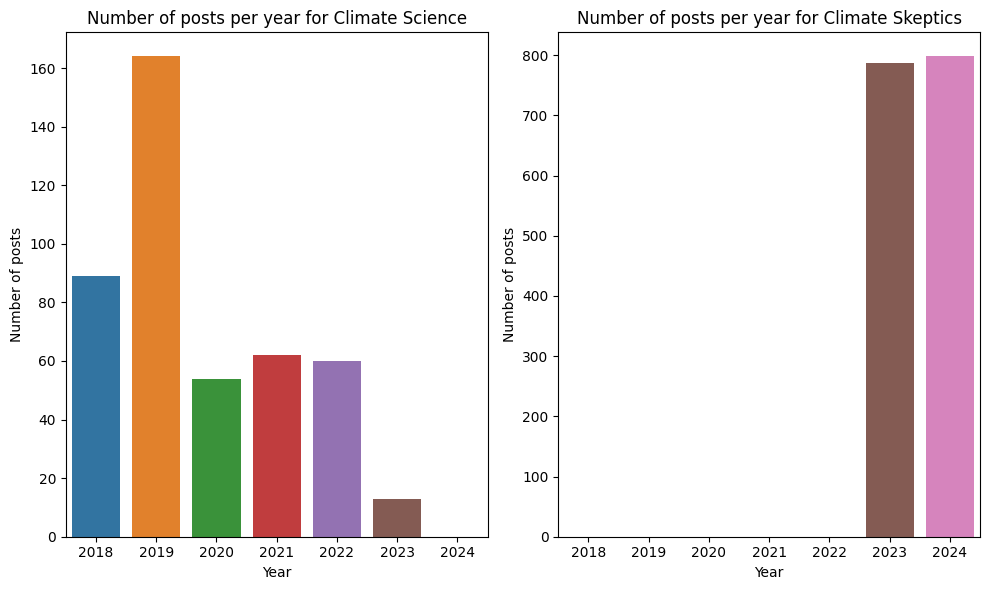

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
sns.countplot(data=df_sci, x='post_year', ax=ax[0], order=range(2018, 2025))
sns.countplot(data=df_skep, x='post_year', ax=ax[1], order=range(2018, 2025))
ax[0].set_title('Number of posts per year for Climate Science')
ax[1].set_title('Number of posts per year for Climate Skeptics')
ax[0].set_xlabel('Year')
ax[1].set_xlabel('Year')
ax[0].set_ylabel('Number of posts')
ax[1].set_ylabel('Number of posts')
plt.tight_layout()
plt.show()


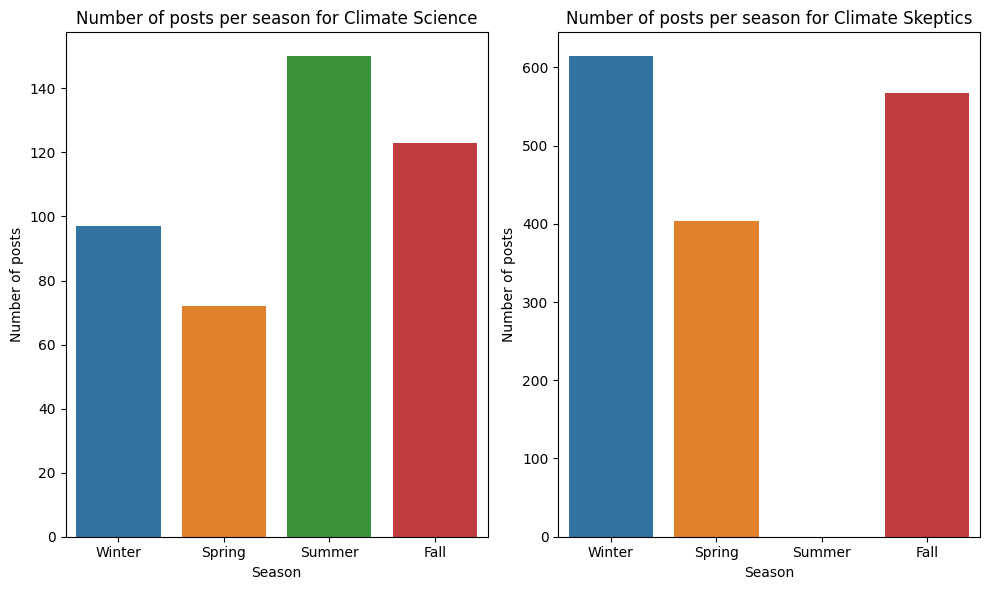

In [11]:
df_sci["season"] = df_sci["post_month"].map({1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall", 10: "Fall", 11: "Fall", 12: "Winter"})
df_skep["season"] = df_skep["post_month"].map({1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall", 10: "Fall", 11: "Fall", 12: "Winter"})
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
sns.countplot(data=df_sci, x='season', ax=ax[0], order=["Winter", "Spring", "Summer", "Fall"])
sns.countplot(data=df_skep, x='season', ax=ax[1], order=["Winter", "Spring", "Summer", "Fall"])
ax[0].set_title('Number of posts per season for Climate Science')
ax[1].set_title('Number of posts per season for Climate Skeptics')
ax[0].set_xlabel('Season')
ax[1].set_xlabel('Season')
ax[0].set_ylabel('Number of posts')
ax[1].set_ylabel('Number of posts')
plt.tight_layout()
plt.show()

In [12]:
#apply to the original dataframe
df["post_created_time"] = pd.to_datetime(df["post_created_time"])
df["post_day"] = df["post_created_time"].dt.day
df["post_month"] = df["post_created_time"].dt.month
df["post_year"] = df["post_created_time"].dt.year
df["post_day_of_week"] = df["post_created_time"].dt.dayofweek
df["post_day_of_year"] = df["post_created_time"].dt.dayofyear
df["post_hour"] = df["post_created_time"].dt.hour
df["season"] = df["post_month"].map({1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall", 10: "Fall", 11: "Fall", 12: "Winter"})


In [13]:
#Chi-square test
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["subreddit"], df["season"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-square test result: for season")
print("Chi2: ", chi2)
print("p-value: ", p)
print("Degree of freedom: ", dof)
print()
contingency_table = pd.crosstab(df["subreddit"], df["post_year"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-square test result: for post year")
print("Chi2: ", chi2)
print("p-value: ", p)
print("Degree of freedom: ", dof)


Chi-square test result: for season
Chi2:  584.54515023556
p-value:  2.2579980953331532e-126
Degree of freedom:  3

Chi-square test result: for post year
Chi2:  1951.9960632074597
p-value:  0.0
Degree of freedom:  6


### Data augmentation

In [14]:
#split 20% of the data as test set, and the rest as training set then, augment the training set
n = len(df)
train_size = int(n * 0.8)
test_size = n - train_size
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]
print(df["subreddit"].value_counts())
#check the distribution of the test_df
test_df["subreddit"].value_counts()

#save train_df and test_df
pkl.dump(train_df, open('train_data.pkl', 'wb'))
pkl.dump(test_df, open('test_data.pkl', 'wb'))

climateskeptics    1585
climate_science     442
Name: subreddit, dtype: int64


In [15]:
print(train_df["subreddit"].value_counts())

climateskeptics    1275
climate_science     346
Name: subreddit, dtype: int64


In [16]:
#data augmentation for climate_science subreddit 
import nlpaug 
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.char as nac
import nlpaug.augmenter.sentence as nas

def augment(text):
    #apply random word substitution
    for i in range(2):
        aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="substitute")
        text = aug.augment(text)
   
    # apply insertion 
    for i in range(2):
        aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="insert")
        text = aug.augment(text)
    
    return text



In [17]:
#for each climate science post, apply the augmentation function
#create an empty df that has the same columns as the original dataframe

# augmented_df = pd.DataFrame(columns=train_df.columns)
# n = len(df_sci)
# cnt = 0
# train_df = pkl.load(open('train_data.pkl', 'rb'))
# print(train_df.shape)
# # iterate over the rows of the dataframe
# for i, row in train_df.iterrows():
#     if row["subreddit"] == "climate_science":
#         text = row["self_text"]
#         #apply augmentation
#         augmented_text = augment(text) 
#         #append the original row to the new dataframe with self_text replaced by augmented_text
#         row["self_text"] = augmented_text
#         augmented_df = augmented_df.append(row)
#         cnt += 1
#         print(f"Augmented {cnt} out of {n} rows")

# new_df = pd.concat([train_df, augmented_df], ignore_index=True)
# new_df.to_pickle("train_data_augmented.pkl")


#PS: Only run this cell when you want to augment the training data

        

In [18]:
train_df = pkl.load(open('train_data_augmented.pkl', 'rb'))
test_df = pkl.load(open('test_data.pkl', 'rb'))

print(train_df["subreddit"].value_counts())
print(test_df["subreddit"].value_counts())

df = pd.concat([train_df, test_df], ignore_index=True)

for row in df.iterrows():
    #if row[1]['self_text'] is a list: get the first element
    if isinstance(row[1]['self_text'], list):
        df.at[row[0], 'self_text'] = row[1]['self_text'][0]

for row in df.iterrows():
    assert isinstance(row[1]['self_text'], str)
    
print(df.shape)
    

climateskeptics    1275
climate_science     692
Name: subreddit, dtype: int64
climateskeptics    310
climate_science     96
Name: subreddit, dtype: int64
(2373, 26)


### Preprocessing Data

In [19]:
df["preprocessed_text"] = df["self_text"].apply(lambda x: x.lower())
stop_words = set(stopwords.words('english'))
df["tokenized_text"] = df["preprocessed_text"].apply(lambda x: word_tokenize(x))
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word not in stop_words])
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word.isalnum()]) 
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if len(word) > 1]) # remove single character words, this can help with removing punctuation. 
lemmitizer = WordNetLemmatizer()
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [lemmitizer.lemmatize(word) for word in x])
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if len(word) > 1]) # remove single character words, this can help with removing punctuation. 
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word.isalnum()]) 



In [20]:
grouped = df.groupby("subreddit")
df_cli_sci = grouped.get_group('climate_science')
df_cli_skp = grouped.get_group('climateskeptics')

print(df_cli_sci.shape)
print(df_cli_skp.shape)

(788, 28)
(1585, 28)


### Word Clouds

In [21]:
cli_sci_words = [word for words in df_cli_sci["tokenized_text"].values for word in words]
cli_skp_words = [word for words in df_cli_skp["tokenized_text"].values for word in words]

In [22]:
common_words = set()
with open ("common_words.txt", "r") as f:
    for line in f:
        common_words.add(line.strip())
        
print(len(common_words))
cli_sci_words = [word for word in cli_sci_words if word not in common_words]
cli_skp_words = [word for word in cli_skp_words if word not in common_words]

63


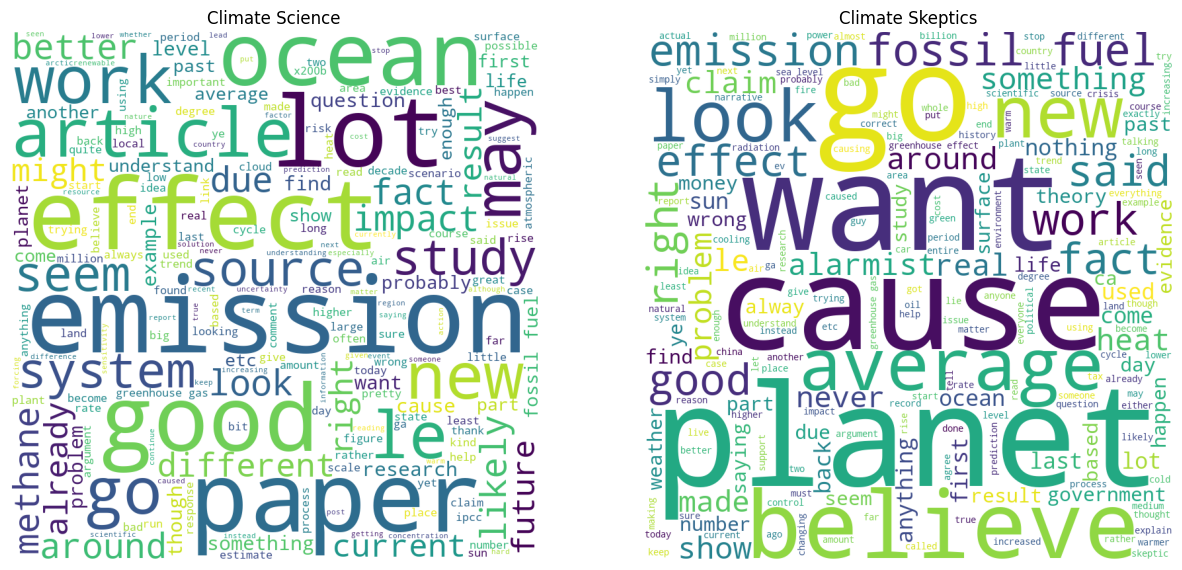

In [23]:
#word cloud for climate science and climate skeptics in subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 15))

wordcloud_cli_sci = WordCloud(width=800, height=800, background_color='white').generate(' '.join(cli_sci_words))
ax[0].imshow(wordcloud_cli_sci)
ax[0].axis('off')
ax[0].set_title('Climate Science')

wordcloud_cli_skp = WordCloud(width=800, height=800, background_color='white').generate(' '.join(cli_skp_words))
ax[1].imshow(wordcloud_cli_skp)
ax[1].axis('off')
ax[1].set_title('Climate Skeptics')

plt.show()

In [24]:
#after we have made a list of common words, we can remove them from the tokenized text
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word not in common_words])
df["preprocessed_text"] = df["tokenized_text"].apply(lambda x: ' '.join(x)) # convert back to string, now each observation is a string of words that has been cleaned

### TF-IDF

In [25]:
 #initialize the vectorizer without any preprocessing
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df["preprocessed_text"]) #fitting and transforming the vectorizer on the preprocessed text 
tfidf_matrix = tfidf_matrix.toarray() #convert object matrix to a matrix
print(tfidf_matrix.shape) 
df["tfidf_vector"] = [vector for vector in tfidf_matrix] #store the vectors in the dataframe for later use

(2373, 28233)


In [26]:
most_prominent_words = ['emission', 'source', 'planet', 'believe']
#find the indices of the most prominent words in the tfidf features 
word_indices = [tfidf_vectorizer.vocabulary_[word] for word in most_prominent_words]
#find the cosine similarity between the most prominent words
cosine_similarities = cosine_similarity(tfidf_matrix[:, word_indices].T)
#store the cosine similarities in a dataframe
cosine_similarities_df = pd.DataFrame(cosine_similarities, columns=most_prominent_words, index=most_prominent_words)
print(cosine_similarities_df)

          emission    source    planet   believe
emission  1.000000  0.231158  0.185450  0.103562
source    0.231158  1.000000  0.141525  0.158225
planet    0.185450  0.141525  1.000000  0.223728
believe   0.103562  0.158225  0.223728  1.000000


### ML models with TF-IDF

In [27]:
X = tfidf_matrix
y = df["subreddit"].values
y = np.array([0 if subreddit == 'climate_science' else 1 for subreddit in y]) #convert the subreddit names to binary values
print(X.shape)
print(y.shape)


X_train, X_test, y_train, y_test = X[:-406], X[-406:], y[:-406], y[-406:] #the last 406 rows are the test set, this is done before the data augmentation step

(2373, 28233)
(2373,)


In [28]:
def train_and_test(model, X_train, X_test, y_train, y_test):
    time_start = time.time()
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1 = precision_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)
    
    time_elapsed = round((time.time() - time_start),3)
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'time_elapsed(s)': time_elapsed}

In [29]:
classifiers = [
    ("Logistic Regression", LogisticRegression()), 
    ("Random Forest", RandomForestClassifier()), 
    ("Naive Bayes", GaussianNB()), 
    ("SVM", SVC())
]
results = {}

for classifier in classifiers:
    name, model = classifier
    results[name] = train_and_test(model, X_train, X_test, y_train, y_test)
    
results_df = pd.DataFrame(results).T
results_df

,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.854680,0.845730,0.990323,0.912333,0.594
Random Forest,0.825123,0.829201,0.970968,0.894502,8.286
Naive Bayes,0.768473,0.805085,0.919355,0.858434,0.638
SVM,0.837438,0.827957,0.993548,0.903226,57.594


In [30]:
from sklearn.feature_selection import SelectKBest, chi2
def select_k(k):
    selector = SelectKBest(score_func=chi2, k=k)
    
    selected_indices = selector.fit(X, y).get_support(indices=True) #get the indices of the selected features

    return selected_indices

#select top k features using tfidf
def select_k_tfidf(k):
    #sum the tfidf scores for each word
    word_scores = np.sum(tfidf_matrix, axis=0)
    #get the indices of the top k words
    top_k_indices = np.argsort(word_scores)[-k:] #sort the indices in ascending order and get the last k indices
     
    return top_k_indices

In [31]:
k_s = [25000, 20000, 15000, 10000, 5000]
pruned_results = {} 
for k in k_s:
    select_indices = select_k(k)
    X_train_k = X_train[:, select_indices]
    X_test_k = X_test[:, select_indices]
    pruned_results[f'RandomForest_{k}'] = train_and_test(RandomForestClassifier(), X_train_k, X_test_k, y_train, y_test)
    
pruned_results_df = pd.DataFrame(pruned_results).T
pruned_results_df

,accuracy,precision,recall,f1,time_elapsed(s)
RandomForest_25000,0.837438,0.837017,0.977419,0.901786,3.772
RandomForest_20000,0.842365,0.836066,0.987097,0.905325,3.153
RandomForest_15000,0.834975,0.829268,0.987097,0.901325,2.651
RandomForest_10000,0.844828,0.840220,0.983871,0.906389,2.098
RandomForest_5000,0.844828,0.842105,0.980645,0.906110,1.458


### Metadata

In [32]:
df['summer'] = df['season'].apply(lambda x: 1 if x == 'Summer' else 0)
df['winter'] = df['season'].apply(lambda x: 1 if x == 'Winter' else 0)
df['spring'] = df['season'].apply(lambda x: 1 if x == 'Spring' else 0)
df['fall'] = df['season'].apply(lambda x: 1 if x == 'Fall' else 0)

optimal_k = 5000  
select_indices = select_k(optimal_k) #select the optimal k features
X_pruned = X[:, select_indices] #select the optimal k features from the original matrix
metadata_features = [   "score", 
                        "user_awardee_karma", 
                        "user_awarder_karma", 
                        "user_total_karma", 
                        "user_comment_karma", 
                        "user_link_karma",
                        # "summer",
                        "fall",
                        "winter",
                        "spring",  
                        # "post_year" 
                     ]

metadata_matrix = df[metadata_features].values
metadata_matrix = preprocessing.StandardScaler().fit_transform(metadata_matrix) # the metadata matrix is standardized

print(metadata_matrix.shape)
print(np.isnan(metadata_matrix).any())



(2373, 9)
True


In [33]:
X_augmented = np.concatenate((X_pruned, metadata_matrix), axis=1) #concatenate the pruned features with the metadata features
print(X_augmented.shape)
rows_with_nan = np.isnan(X_augmented).any(axis=1) #check if there are any rows with NaN values
X_augmented = X_augmented[~rows_with_nan] #remove the rows with NaN values
y_augmented = y[~rows_with_nan] #remove the corresponding labels
print(X_augmented.shape)

(2373, 5009)
(2368, 5009)


In [34]:
X_train_augmented, X_test_augmented, y_train_augmented, y_test_augmented = train_test_split(X_augmented, y_augmented, test_size=0.2)
augmented_results = {}

for classifier in classifiers:
    name, model = classifier
    augmented_results[name] = train_and_test(model, X_train_augmented, X_test_augmented, y_train_augmented, y_test_augmented)
    
augmented_results_df = pd.DataFrame(augmented_results).T
augmented_results_df


,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.848101,0.811518,1.000000,0.895954,0.198
Random Forest,0.907173,0.884393,0.987097,0.932927,1.540
Naive Bayes,0.905063,0.890855,0.974194,0.930663,0.120
SVM,0.776371,0.748780,0.990323,0.852778,5.863


In [35]:
#combine results and augmented results
results_df = pd.concat([results_df, augmented_results_df], axis=0)
results_df


,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.854680,0.845730,0.990323,0.912333,0.594
Random Forest,0.825123,0.829201,0.970968,0.894502,8.286
Naive Bayes,0.768473,0.805085,0.919355,0.858434,0.638
SVM,0.837438,0.827957,0.993548,0.903226,57.594
Logistic Regression,0.848101,0.811518,1.000000,0.895954,0.198
Random Forest,0.907173,0.884393,0.987097,0.932927,1.540
Naive Bayes,0.905063,0.890855,0.974194,0.930663,0.120
SVM,0.776371,0.748780,0.990323,0.852778,5.863


In [36]:
# output top 5000 words to a file, run only once
# top_k_indices = set(select_k_tfidf(5000))
# top_words = [word for word, idx in tfidf_vectorizer.vocabulary_.items() if idx in top_k_indices]

# with open("top_5000.txt", "w") as f:
#     for word in top_words:
#         f.write(word + "\n")



### Word2Vec ML models

In [37]:
top_5000_words = set()
with open("top_5000.txt", "r") as f:
    for line in f:
        top_5000_words.add(line.strip())
        
df["preprocessed_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word in top_5000_words])

In [38]:
import gensim.downloader as api
word2vec_model = api.load('word2vec-google-news-300')

In [39]:
most_prominent_words = ['emission', 'source', 'planet', 'believe']
cosine_similarities = cosine_similarity(word2vec_model[most_prominent_words])

cos_sim_df = pd.DataFrame(cosine_similarities, columns=most_prominent_words, index=most_prominent_words)
cos_sim_df

,emission,source,planet,believe
emission,1.000000,0.050124,0.215118,0.022043
source,0.050124,1.000000,0.107579,0.044794
planet,0.215118,0.107579,1.000000,0.084979
believe,0.022043,0.044794,0.084979,1.000000


In [40]:
df["avg_sentence_vector"] = df["preprocessed_text"].apply(lambda x: np.mean([word2vec_model[word] for word in x if word in word2vec_model.key_to_index], axis=0))

#check the dimension of the average sentence vector of each post
df["avg_sentence_vector"].apply(lambda x: x.shape).value_counts()
df = df.dropna(subset=["avg_sentence_vector"])
print(df.shape)

(2366, 34)


In [41]:
X = np.array(df["avg_sentence_vector"].values.tolist())
y = df["subreddit"].apply(lambda x: 0 if x == "climate_science" else 1)
X_train, X_test, y_train, y_test = X[:-406], X[-406:], y[:-406], y[-406:]

In [42]:
classifiers = [
    ("Logistic Regression", LogisticRegression()), 
    ("Random Forest", RandomForestClassifier()), 
    ("Naive Bayes", GaussianNB()), 
    ("SVM", SVC())
]
results = {}

for classifier in classifiers:
    name, model = classifier
    results[name] = train_and_test(model, X_train, X_test, y_train, y_test)

results_df = pd.DataFrame(results).T
results_df

,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.854680,0.885449,0.928571,0.906498,0.020
Random Forest,0.847291,0.859649,0.954545,0.904615,1.544
Naive Bayes,0.655172,0.907767,0.607143,0.727626,0.007
SVM,0.874384,0.900312,0.938312,0.918919,0.161


In [43]:
tfidf = TfidfVectorizer()
documents = df["preprocessed_text"].apply(lambda x: ' '.join(x))
tf_idf_matrix = tfidf.fit_transform(documents)

def compute_tfidf_avg_vector(doc_index, words):
    vectors = []
    for word in words:
        if word in word2vec_model.key_to_index and word in tfidf.vocabulary_:
            tfidf_weight = tf_idf_matrix[doc_index, tfidf.vocabulary_[word]]
            word_vector = word2vec_model[word]
            vectors.append(tfidf_weight * word_vector)
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return None

df["tfidf_avg_sentence_vector"] = [compute_tfidf_avg_vector(i, words) for i, words in enumerate(df["preprocessed_text"])]

#remove rows with NaN values
df = df.dropna(subset=["tfidf_avg_sentence_vector"])
df.shape

(2366, 35)

In [44]:
X = np.array(df["tfidf_avg_sentence_vector"].values.tolist())
y = df["subreddit"].apply(lambda x: 0 if x == "climate_science" else 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

tfidf_results = {}

for classifier in classifiers:
    name, model = classifier
    tfidf_results[name] = train_and_test(model, X_train, X_test, y_train, y_test)
    
tfidf_results_df = pd.DataFrame(tfidf_results).T
tfidf_results_df

,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.662447,0.660981,0.996785,0.794872,0.016
Random Forest,0.782700,0.776596,0.938907,0.850073,1.479
Naive Bayes,0.377637,0.625000,0.128617,0.213333,0.008
SVM,0.763713,0.757106,0.942122,0.839542,0.198


In [45]:
#create metadata features
metadata_features = [   "score", 
                        "user_awardee_karma", 
                        "user_awarder_karma", 
                        "user_total_karma", 
                        "user_comment_karma", 
                        "user_link_karma",
                        # "summer",
                        "fall",
                        "winter",
                        "spring",  
                        # "post_year" 
                     ]
metadata_matrix = df[metadata_features].values
metadata_matrix = preprocessing.StandardScaler().fit_transform(metadata_matrix) # the metadata matrix is standardized


In [46]:
X = df["avg_sentence_vector"].values.tolist()
X = np.concatenate([X, metadata_matrix], axis=1)
y = df["subreddit"].apply(lambda x: 0 if x == "climate_science" else 1)

#delete rows with NaN values in X and y
nan_indices = np.isnan(X).any(axis=1)
X = X[~nan_indices]
y = y[~nan_indices]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

metadata_results = {}

for classifier in classifiers:
    name, model = classifier
    metadata_results[name] = train_and_test(model, X_train, X_test, y_train, y_test)
    
metadata_results_df = pd.DataFrame(metadata_results).T
metadata_results_df


,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.860465,0.847645,0.965300,0.902655,0.024
Random Forest,0.881607,0.869688,0.968454,0.916418,1.494
Naive Bayes,0.784355,0.871972,0.794953,0.831683,0.011
SVM,0.797040,0.772840,0.987382,0.867036,0.164


### DL Models

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

#build the embedding matrix using the top 5000 words
embedding_matrix =[[0] * 300] #this matrix will contain the word embeddings for the top 5000 words #the first row will be the embedding for the padding token which is 0
word_indices = {} #this dictionary will map each word to its index in the embedding matrix, this is needed when we train the neural network, the input to the neural network will be the index of the word in the embedding matrix
idx = 1
for i, word in enumerate(top_5000_words):
    if word in word2vec_model.key_to_index:
        embedding_matrix.append(word2vec_model[word])
        word_indices[word] = idx
        idx += 1
    
    else:
        continue
embedding_matrix = np.array(embedding_matrix)
print(embedding_matrix.shape)

(4742, 300)


In [48]:
#LSTM 
class LSTMClf(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, embedding_matrix, device):
        super(LSTMClf, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # self.embedding = nn.Embedding(embedding_matrix.shape[0], embedding_matrix.shape[1])
        # self.embedding.load_state_dict({'weight': torch.FloatTensor(embedding_matrix)})
        # self.embedding.weight.requires_grad = False #freeze the embedding layer
        self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(embedding_matrix), padding_idx=0, freeze=True)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, 32)
        self.output = nn.Linear(32, 1)
        self.device = device
        
    def forward(self, x):
        #randomly initialize the hidden state and cell state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        
        out = self.embedding(x)
        out, _ = self.lstm(out, (h0, c0))
        out = self.fc(out[:, -1, :]).relu()
        out = self.output(out)
        return out
    

class RNNClf(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, embedding_matrix, device):
        super(RNNClf, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(embedding_matrix.shape[0], embedding_matrix.shape[1])
        self.embedding.load_state_dict({'weight': torch.FloatTensor(embedding_matrix)})
        self.embedding.weight.requires_grad = False #freeze the embedding layer
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True) 
        self.fc = nn.Linear(hidden_size, 32)
        self.output = nn.Linear(32, 1)
        self.device = device
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        
        out = self.embedding(x)
        out, _ = self.rnn(out, h0)
        out = self.fc(out[:, -1, :]).relu()
        out = self.output(out)
        return out
    
class CNNClf(nn.Module):
    def __init__(self, input_size, hidden_size, embedding_matrix):
        super(CNNClf, self).__init__()
        self.embedding = nn.Embedding(embedding_matrix.shape[0], embedding_matrix.shape[1])
        self.embedding.load_state_dict({'weight': torch.FloatTensor(embedding_matrix)})
        self.embedding.weight.requires_grad = False
        
        self.conv1 = nn.Conv1d(input_size, hidden_size, kernel_size=3) #output size = (input_size - kernel_size + 1) = (300 - 3 + 1) = 298 
        
        self.fc = nn.Linear(hidden_size * 298, 64)  # 298 is the output size of the convolutional layer
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

        
    def forward(self, x):
        out = self.embedding(x)
        out = self.conv1(out).relu()
        out = out.flatten(1)
        out = self.fc(out).relu()
        out = self.fc2(out).relu()
        out = self.fc3(out)
        return out
    
    
class BiLSTMClf(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, embedding_matrix, device):
        super(BiLSTMClf, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(embedding_matrix.shape[0], embedding_matrix.shape[1])
        self.embedding.load_state_dict({'weight': torch.FloatTensor(embedding_matrix)})
        self.embedding.weight.requires_grad = False
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True) 
        self.fc = nn.Linear(hidden_size * 2, 32)
        self.output = nn.Linear(32, 1)
        self.device = device
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(self.device)
        c0  = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(self.device)
        
        out = self.embedding(x)
        out, _ = self.lstm(out, (h0, c0)) 
        out = self.fc(out[:, -1, :]).relu()
        out = self.output(out)
        return out

In [49]:
def padding(sequence, max_len):
    if len(sequence) <= max_len:
        sequences = [sequence + [0] * (max_len - len(sequence))]
    
    elif len(sequence) > max_len:
        #break sequence into chunks of max_len
        sequences = []
        while len(sequence) > max_len:
            sequences.append(sequence[:max_len])
            sequence = sequence[max_len:]
        #if the last chunk is less than max_len, then pad it with zeros
        if len(sequences[-1]) < max_len and len(sequences[-1]) > 5:
            sequences[-1] += [0] * (max_len - len(sequences[-1]))
    
    for seq in sequences:
        assert len(seq) == max_len
    return sequences
        

In [50]:
def prepare_data(df, word_indices, max_len):
    X = []
    y = []
    for i, row in df.iterrows():
        
        sequence = [word_indices[word] for word in row["preprocessed_text"] if word in word_indices and word in word2vec_model.key_to_index]
        sequences = padding(sequence, max_len)
        X += sequences
        if row["subreddit"] == "climate_science":
            y += [0] * len(sequences)
        else:
            y += [1] * len(sequences)
    
    # print(len(X[2]))
    #convert X and y to numpy arrays then to tensors
    X = torch.tensor(X).clone().detach()
    y = torch.tensor(y).float().clone().detach()
    return X, y

In [51]:
#prepare the data  
batch_size = 32
max_len = 100
X_train, y_train = prepare_data(df[:-406], word_indices, max_len)
num_0_class = len(y) - sum(y)
num_1_class = sum(y)
print(num_0_class, num_1_class)

X_test, y_test = prepare_data(df[-406:], word_indices, max_len)
# X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
#find number of each class in the training set

#convert the data into data loaders
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# val_dataset = TensorDataset(X_val, y_val)
# val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

print(len(train_loader), len(test_loader))

for x, y in train_loader:
    print(x.shape, y.shape)
    break

786 1575
132 25
torch.Size([32, 100]) torch.Size([32])


In [52]:
def train(train_data, validation_data, criterion, optimizer, device, model, num_epochs):
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        train_corr = 0
        total_train = 0

        for x, y in train_data:
            # Send data to the correct device
            x, y = x.to(device), y.to(device).float()
            y = y.unsqueeze(1)  # Ensure y has correct shape for binary classification
            total_train += y.size(0)
            
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            total_loss += loss.item() 

            # Calculate training accuracy
            train_corr += ((output > 0.5).float() == y).sum().item()
            
            loss.backward()
            optimizer.step()
        
        train_losses.append(total_loss / len(train_data))
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y in validation_data:
                x, y = x.to(device), y.to(device).float()
                y = y.unsqueeze(1)
                output = model(x)
                val_loss += criterion(output, y).item()
            
            val_losses.append(val_loss / len(validation_data))
        
        # Display metrics
        train_accuracy = 100 * train_corr / total_train
        # print(f"Epoch {epoch + 1}/{num_epochs}, Training Loss: {train_losses[-1]:.4f}, "
        #       f"Train Accuracy: {train_accuracy:.2f}%, Validation Loss: {val_losses[-1]:.4f}")


    return train_losses, val_losses


def test(test_data, model, device):
    model.eval()
    y_pred = []
    y_true = []
    
    with torch.no_grad():
        for x, y in test_data:
            x, y = x.to(device), y.to(device).float()
            output = model(x).squeeze(1)
            
            # Collect predictions and true labels as lists of integers
            y_pred.extend((output > 0.5).int().cpu().tolist())
            y_true.extend(y.int().cpu().tolist())

    # Ensure that y_true is the first argument in the metric functions
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Test Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

    return accuracy, precision, recall, f1
            

In [53]:
#hyperparameters
input_size = 300
hidden_size = 16
num_layers = 2
num_classes = 1
learning_rate = 0.01
num_epochs = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
criterion = torch.nn.BCEWithLogitsLoss() 


cuda


Training LSTMClf
Test Accuracy: 0.7711, Precision: 0.8838, Recall: 0.8050, F1 Score: 0.8426





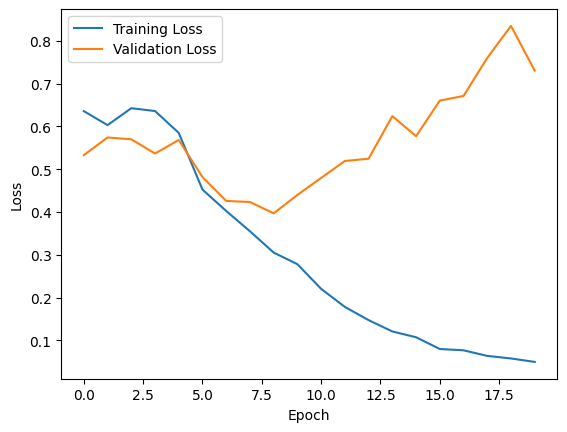

Training CNNClf
Test Accuracy: 0.8063, Precision: 0.8311, Recall: 0.9355, F1 Score: 0.8802





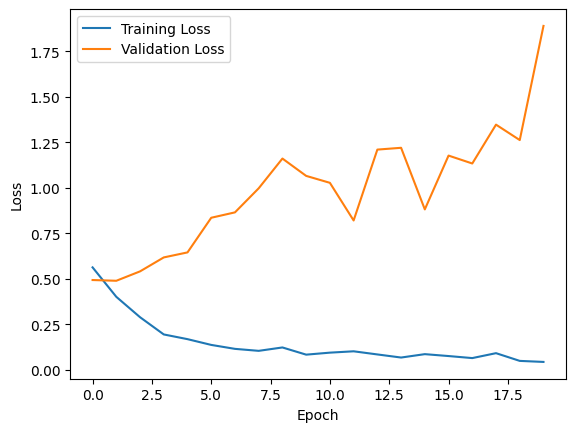

Training RNNClf
Test Accuracy: 0.6428, Precision: 0.7851, Recall: 0.7306, F1 Score: 0.7568





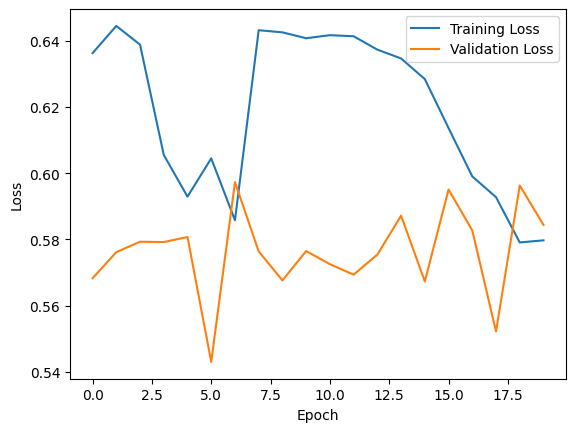

Training BiLSTMClf
Test Accuracy: 0.8201, Precision: 0.8702, Recall: 0.8975, F1 Score: 0.8836





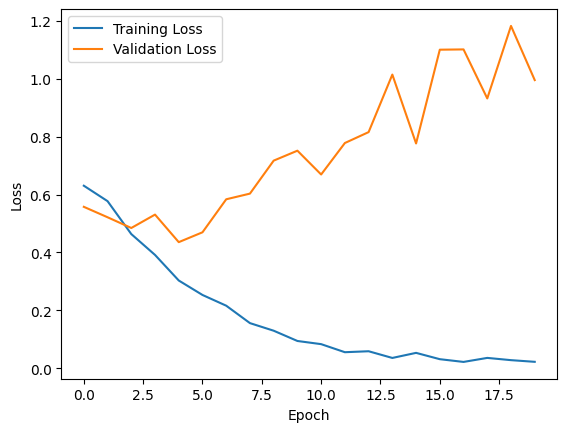

In [54]:
lstm_clf = LSTMClf(input_size, hidden_size, num_layers, num_classes, embedding_matrix, device).to(device)
rnn_clf = RNNClf(input_size, hidden_size, num_layers, num_classes, embedding_matrix, device).to(device)
cnn_clf = CNNClf(100, hidden_size, embedding_matrix).to(device)
bi_lstm_clf = BiLSTMClf(input_size, hidden_size, num_layers, num_classes, embedding_matrix, device).to(device)

#optimizer
models = [lstm_clf, cnn_clf, rnn_clf, bi_lstm_clf]
dl_results = {}
for model in models:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate) 
    print(f"Training {model.__class__.__name__}")
    train_losses, val_losses = train(train_loader, test_loader, criterion, optimizer, device, model, num_epochs)
    accuracy, precision, recall, f1 = test(test_loader, model, device)
    dl_results[model.__class__.__name__] = {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}
    print("\n\n")
    #plot the training and validation losses
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.show()

In [55]:
dl_results_df = pd.DataFrame(dl_results).T
dl_results_df

,accuracy,precision,recall,f1
LSTMClf,0.771069,0.883848,0.804959,0.842561
CNNClf,0.806289,0.831131,0.935537,0.880249
RNNClf,0.642767,0.785080,0.730579,0.756849
BiLSTMClf,0.820126,0.870192,0.897521,0.883645


### LLM

In [ ]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()

def bert_word_embedding(word):
    tokenized = tokenizer(word, return_tensors='pt')

    with torch.no_grad():
        output = model(**tokenized)
    return output.last_hidden_state.mean(dim=1).squeeze(0).numpy()

bert_embedding_matrix = {}
for word in top_5000_words:
    bert_embedding_matrix[word] = bert_word_embedding(word)






In [80]:
most_prominent_words = ['emission', 'source', 'planet', 'believe']
cosine_similarities = cosine_similarity([bert_embedding_matrix[word] for word in most_prominent_words])
cos_sim_df = pd.DataFrame(cosine_similarities, columns=most_prominent_words, index=most_prominent_words)
cos_sim_df

,emission,source,planet,believe
emission,1.000000,0.591276,0.879557,0.860740
source,0.591276,1.000000,0.646898,0.580835
planet,0.879557,0.646898,1.000000,0.845843
believe,0.860740,0.580835,0.845843,1.000000


### AVG, MAX, TF-IDF-Weighted

In [81]:
df["bert_avg_sentence_vector"] = df["preprocessed_text"].apply(lambda x: np.mean([bert_embedding_matrix[word] for word in x if word in bert_embedding_matrix], axis=0))


In [82]:
X = np.array(df["bert_avg_sentence_vector"].values.tolist())
y = df["subreddit"].apply(lambda x: 0 if x == "climate_science" else 1)

X_train, X_test, y_train, y_test = X[:-406], X[-406:], y[:-406], y[-406:]

bert_results = {}
classifiers = [
    ("Logistic Regression", LogisticRegression()), 
    ("Random Forest", RandomForestClassifier()), 
    ("Naive Bayes", GaussianNB()), 
    ("SVM", SVC())
]

for classifier in classifiers:
    name, model = classifier
    bert_results[name] = train_and_test(model, X_train, X_test, y_train, y_test)
    
bert_results_df = pd.DataFrame(bert_results).T
bert_results_df


,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.830049,0.865443,0.918831,0.891339,0.037
Random Forest,0.825123,0.837607,0.954545,0.892261,2.485
Naive Bayes,0.593596,0.878307,0.538961,0.668008,0.015
SVM,0.768473,0.766169,1.000000,0.867606,0.737


In [84]:
def compute_tfidf_avg_vector(doc_index, words):
    vectors = []
    for word in words:
        if word in tfidf.vocabulary_:
            tfidf_weight = tf_idf_matrix[doc_index, tfidf.vocabulary_[word]]
            word_vector = bert_embedding_matrix[word]
            vectors.append(tfidf_weight * word_vector)
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return None
    
df["tfidf_avg_sentence_vector"] = [compute_tfidf_avg_vector(i, words) for i, words in enumerate(df["preprocessed_text"])]
bert_results = {}
X = np.array(df["tfidf_avg_sentence_vector"].values.tolist())
y = df["subreddit"].apply(lambda x: 0 if x == "climate_science" else 1)

X_train, X_test, y_train, y_test = X[:-406], X[-406:], y[:-406], y[-406:]

for classifier in classifiers:
    name, model = classifier
    bert_results[name] = train_and_test(model, X_train, X_test, y_train, y_test)

bert_results_df = pd.DataFrame(bert_results).T
bert_results_df


,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.763547,0.767677,0.987013,0.863636,0.020
Random Forest,0.785714,0.799458,0.957792,0.871492,2.619
Naive Bayes,0.305419,0.740741,0.129870,0.220994,0.014
SVM,0.766010,0.764268,1.000000,0.866385,0.602


In [85]:
#max aggregation
df["max_sentence_vector"] = df["preprocessed_text"].apply(lambda x: np.max([bert_embedding_matrix[word] for word in x if word in bert_embedding_matrix], axis=0))

X = np.array(df["max_sentence_vector"].values.tolist())
y = df["subreddit"].apply(lambda x: 0 if x == "climate_science" else 1)

X_train, X_test, y_train, y_test = X[:-406], X[-406:], y[:-406], y[-406:]

max_results = {}
for classifier in classifiers:
    name, model = classifier
    max_results[name] = train_and_test(model, X_train, X_test, y_train, y_test)
    
max_results_df = pd.DataFrame(max_results).T
max_results_df

,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.839901,0.895765,0.892857,0.894309,0.063
Random Forest,0.788177,0.787565,0.987013,0.876081,1.872
Naive Bayes,0.514778,0.800000,0.480519,0.600406,0.014
SVM,0.807882,0.826705,0.944805,0.881818,0.540


In [95]:
def bert_sentence_embedding(sentence):
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertModel.from_pretrained('bert-base-uncased')
    tokenized = tokenizer(sentence, return_tensors='pt', padding=True, truncation=True)
    
    with torch.no_grad():
        output = model(**tokenized)
    return output.last_hidden_state[:, 0, :].squeeze(0).numpy() #use the CLS token as the sentence embedding

df["bert_sentence_vector"] = df["preprocessed_text"].apply(lambda x: bert_sentence_embedding(' '.join(x)))



In [96]:
pkl.dump(df, open('bert_augmented.pkl', 'wb'))

In [97]:
bert_results = {}
X = np.array(df["bert_sentence_vector"].values.tolist())
y = df["subreddit"].apply(lambda x: 0 if x == "climate_science" else 1)

X_train, X_test, y_train, y_test = X[:-406], X[-406:], y[:-406], y[-406:]

for classifier in classifiers:
    name, model = classifier
    bert_results[name] = train_and_test(model, X_train, X_test, y_train, y_test)
    
bert_results_df = pd.DataFrame(bert_results).T
bert_results_df

,accuracy,precision,recall,f1,time_elapsed(s)
Logistic Regression,0.825123,0.881029,0.889610,0.885299,0.063
Random Forest,0.802956,0.839286,0.915584,0.875776,3.032
Naive Bayes,0.697044,0.874494,0.701299,0.778378,0.014
SVM,0.849754,0.873112,0.938312,0.904538,0.445


### Fine Tuning Bert

In [ ]:
#fine tuning the bert model
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, random_split

# Load the BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Tokenize all of the sentences and map the tokens to thier word IDs